In [1]:
import numpy as np
import pandas as pd
import os
import scipy.io as sio
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from numpy.matlib import repmat
from sklearn.preprocessing import normalize
from PIL import Image

In [2]:
print(os.getcwd())

c:\Users\ravim\Desktop\UCSD 2025-2026\COGS 118B\COGS118B-FinalProject


In [3]:
data = []

# defines folder with direction-facing faces
right_faces = os.getcwd() + "/data_R/"
left_faces = os.getcwd() + "/data_L/"
front_faces = os.getcwd() + "/data_F/"

# using right faces
folder = right_faces

for filename in os.listdir(folder):
    img_path = os.path.join(folder, filename)
    if os.path.isdir(img_path):
        continue
    if not filename.lower().endswith((".jpg", ".jpeg")):
        continue
        
    img = Image.open(img_path).convert("L")   # make image gray
    data.append(img)

faces = np.array(data)
print("Data matrix shape:", faces.shape)

Data matrix shape: (100, 1024, 1024)


In [4]:
def viewcolumn(columnvector):
    # viewcolumn(columnvector)
    plt.imshow(meanface, cmap='gray')
    plt.axis('off')


def normc(Mat):
    # normc(M) normalizes the columns of M to a length of 1
    return normalize(Mat, norm='l2', axis=0)

def viewface(n):
    # to view the nth face (to view 10th, write n=9)
    plt.imshow(faces[n], cmap='gray')
    plt.axis('off')

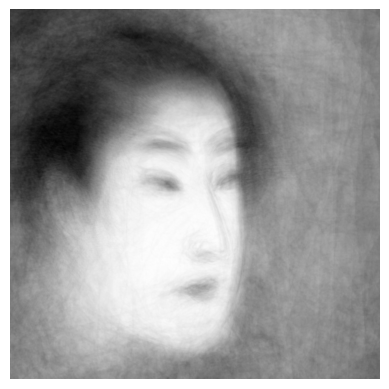

In [5]:
meanface = np.mean(faces,axis=0)

viewcolumn(meanface)

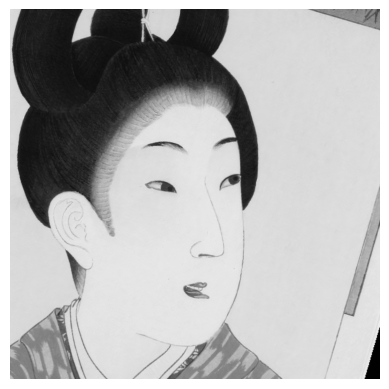

In [6]:
viewface(10)

notes:
1. made data 1D below so we can do 1D math (data reduction) for PCA, but then convert to 2D again (1024x1024) to display images

In [7]:
data_flat = []

for filename in os.listdir(folder):
    img_path = os.path.join(folder, filename)
    if os.path.isdir(img_path):
        continue
    if not filename.lower().endswith((".jpg", ".jpeg")):
        continue
        
    img = Image.open(img_path).convert("L")   # make image gray
    arr = np.array(img).flatten(order="C")             # flatten to 1D vector
    data_flat.append(arr)

faces_flat = np.array(data_flat)
print("Data matrix shape:", faces_flat.shape)

Data matrix shape: (100, 1048576)


In [8]:
def viewcolumnflat(columnvector):
    # viewcolumn(columnvector)
    columnvector = columnvector.reshape(1024,1024)
    plt.imshow(columnvector, cmap='gray')
    plt.axis('off')

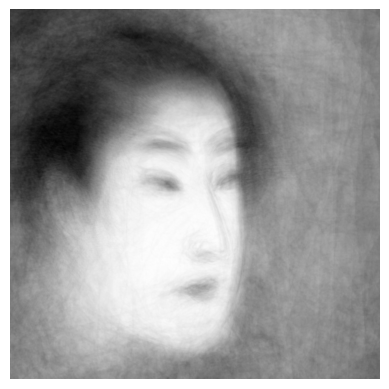

In [9]:
meanface_flat = np.mean(faces_flat,axis=0, keepdims=True)

viewcolumnflat(meanface_flat)

memory is not working here (issue with the code probably) - come back and fix below:

In [10]:
import scipy.sparse as sc

In [11]:
# come back to this: likely messed up the tranposing somewhere ??

print(faces_flat.shape)
faces_flat = np.array(data_flat).T
print(faces_flat.shape)
print(meanface_flat.shape)
meanface_flat = meanface_flat = np.array(meanface_flat).T
print(meanface_flat.shape)

(100, 1048576)
(1048576, 100)
(1, 1048576)
(1048576, 1)


In [12]:
A = faces_flat - np.matlib.repmat(meanface_flat, 1, 100)
eigvals, V = np.linalg.eigh(A.T @ A)
index = np.argsort(-eigvals)
eigvals = eigvals[index]
V = V[:, index]

# choose how many eigenfaces to keep
k = 6
V = V[:, :k]
U = A @ V

In [13]:
# note to self: imaginary part is 0 (0.j) in all values, so can disregard (see below)
U

array([[ 206.33419946, -216.28348174, -101.98563746,   84.58399009,
         -61.56699432,  -38.67572849],
       [ 226.7588113 , -206.41544008,  -97.64967308,   81.27544307,
         -79.47134199,  -13.85601055],
       [ 227.4018241 , -201.49002171, -101.14526162,   82.80605964,
         -79.33531367,  -24.96719804],
       ...,
       [ 356.7453708 ,  -43.50914662, -211.28145467, -125.83782763,
         190.21882264, -171.05177851],
       [ 348.26784442,  -46.89768593, -184.66380764, -106.98670977,
         219.10301578, -157.1313696 ],
       [ 360.32757747,  -45.74220153, -175.35637791, -101.72451844,
         216.08873752, -150.61063313]], shape=(1048576, 6))

In [14]:
U = U.astype(float)
U = normc(U)

In [15]:
U.shape

(1048576, 6)

In [16]:
faces_flat.shape

(1048576, 100)

In [17]:
face1 = faces_flat[:, 1][:, None]
c = U.T @ (face1 - meanface_flat)

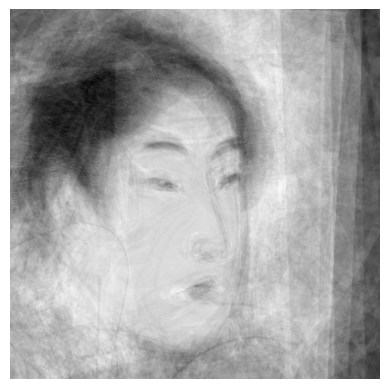

In [18]:
Zhat = U @ c + meanface_flat

viewcolumnflat(Zhat)

notes:
1. split faces into left, right, and front facing
2. run 3 separate PCA reconstructions using these for face alignment (i.e. reconstruct right facing face w/ right faces PCA)
3. try and compare these faces to faces in CLIP and see where things point (?), and then can try to add in another face (e.g. one of our faces) and see if it can stylistically transfer 

disney face reconstruction

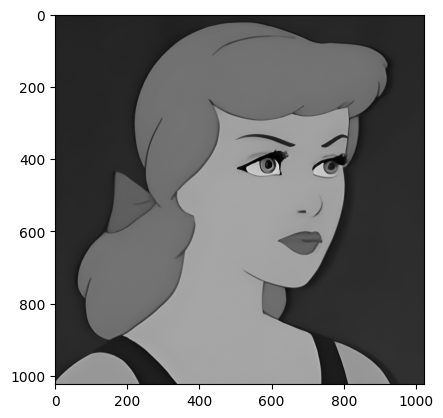

In [26]:
# show disney face, 2D array

image_path = 'disney_face_R.jpg'
img = Image.open(image_path)
img_gray = img.convert('L')
img_resized = img_gray.resize((1024, 1024))
img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
face = img_flatten.reshape((1048576, 1))

plt.imshow(img_arr, cmap='gray')
plt.show()

In [29]:
c = U.T @ (face - meanface_flat)
Zhat = (U @ c) + meanface_flat

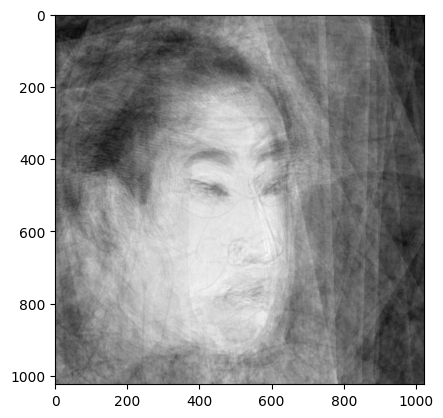

In [30]:
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

sam reconstruction!

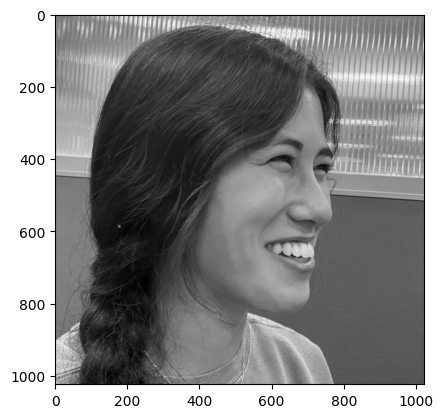

In [ ]:
# show sam face, 2D array

image_path = 'team_faces/sammm.jpeg'
img = Image.open(image_path)
img_gray = img.convert('L')
img_resized = img_gray.resize((1024, 1024))
img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
face = img_flatten.reshape((1048576, 1))

plt.imshow(img_arr, cmap='gray')
plt.show()

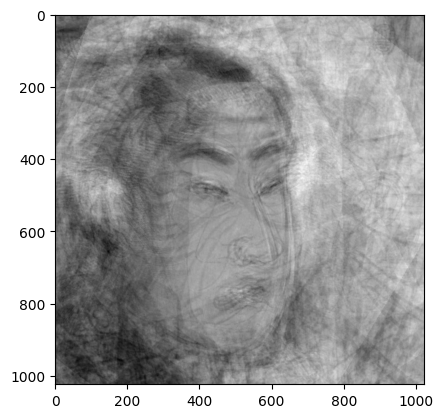

In [34]:
c = U.T @ (face - meanface_flat)
Zhat = (U @ c) + meanface_flat
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

aidan reconstruction!!

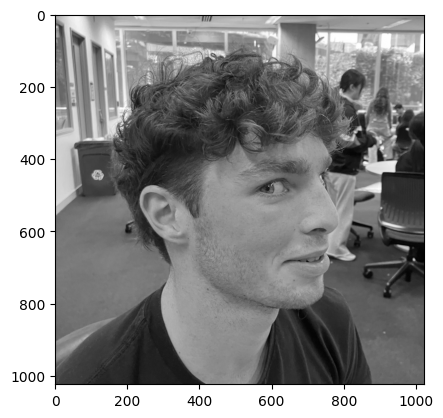

In [ ]:
# show aidan face, 2D array

image_path = 'team_faces/aidannn.jpeg'
img = Image.open(image_path)
img_gray = img.convert('L')
img_resized = img_gray.resize((1024, 1024))
img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
face = img_flatten.reshape((1048576, 1))

plt.imshow(img_arr, cmap='gray')
plt.show()

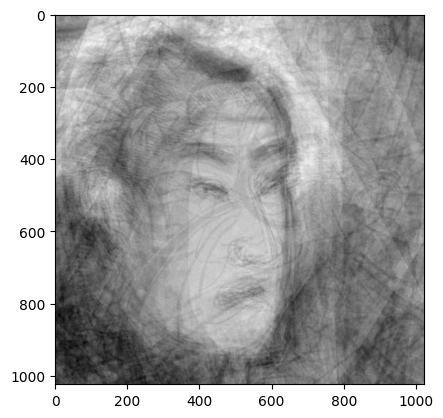

In [37]:
c = U.T @ (face - meanface_flat)
Zhat = (U @ c) + meanface_flat
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

ronin reconstruction!!

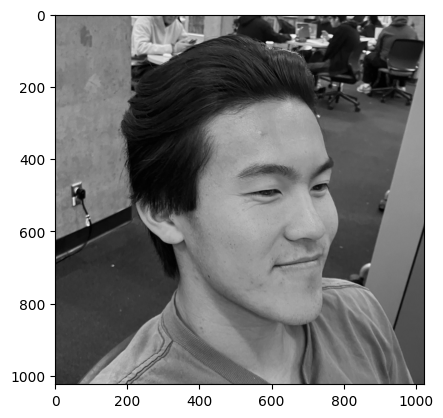

In [38]:
# show ronin face, 2D array

image_path = 'team_faces/roninnn.jpeg'
img = Image.open(image_path)
img_gray = img.convert('L')
img_resized = img_gray.resize((1024, 1024))
img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
face = img_flatten.reshape((1048576, 1))

plt.imshow(img_arr, cmap='gray')
plt.show()

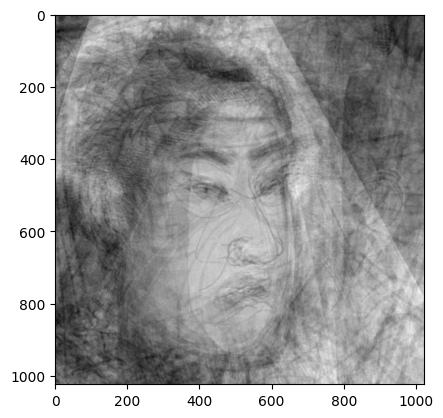

In [39]:
c = U.T @ (face - meanface_flat)
Zhat = (U @ c) + meanface_flat
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')